# Earthquake Zone Clustering using HDBSCAN

This notebook uses only **HDBSCAN** for earthquake zone clustering.

Workflow:

1. Load the earthquake dataset
2. Inspect the data
3. Select numeric features
4. Check correlation and multicollinearity risk
5. Scale the features
6. Choose HDBSCAN parameters with clear reasoning
7. Train HDBSCAN
8. Evaluate cluster quality
9. Visualize clusters using geography and PCA
10. Save the final clustered dataset

This is unsupervised learning, so there is no target label. We evaluate cluster quality using internal clustering metrics.

## 1. Install Required Libraries

Run this cell once if the libraries are not already installed.

In [1]:
%pip install pandas numpy scikit-learn hdbscan matplotlib seaborn

## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import hdbscan

from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 3. Load Dataset

In [3]:
data_path = r"C:\\Users\\Praveen\\Downloads\\earthquake_dataset.csv"

df = pd.read_csv("earthquake_dataset.csv")

df.head()

,Date,Time (UTC),City,Country,Latitude,Longitude,Earthquake Magnitude,Depth (km),Impact Score
0,2025-03-15,16:28:36,55 km NNW of Finschhafen,Papua New Guinea,-6.1233,147.5932,5.1,59.033,400
1,2025-03-15,03:19:27,5 km ESE of San Miguel Achiutla,Mexico,17.2871,-97.4400,5.6,63.551,503
2,2025-03-14,23:42:35,South Sandwich Islands region,South Sandwich Islands region,-55.7385,-27.1122,6.0,35.379,554
3,2025-03-14,19:37:15,15 km NNE of Lesina,Italy,41.9788,15.4490,5.0,8.742,389
4,2025-03-14,11:13:32,229 km N of Palu,Indonesia,1.1364,120.2317,5.4,26.072,449


In [4]:
df.shape

(16944, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16944 entries, 0 to 16943
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  16944 non-null  object 
 1   Time (UTC)            16944 non-null  object 
 2   City                  16944 non-null  object 
 3   Country               16944 non-null  object 
 4   Latitude              16944 non-null  float64
 5   Longitude             16944 non-null  float64
 6   Earthquake Magnitude  16944 non-null  float64
 7   Depth (km)            16944 non-null  float64
 8   Impact Score          16944 non-null  int64  
dtypes: float64(4), int64(1), object(4)
memory usage: 1.2+ MB


## 4. Basic Data Check

In [6]:
df.isnull().sum()

,0
Date,0
Time (UTC),0
City,0
Country,0
Latitude,0
Longitude,0
Earthquake Magnitude,0
Depth (km),0
Impact Score,0


In [7]:
df.describe()

,Latitude,Longitude,Earthquake Magnitude,Depth (km),Impact Score
count,16944.000000,16944.000000,16944.000000,16944.000000,16944.00000
mean,-3.207032,31.839994,5.333485,53.202267,455.21636
std,30.580708,123.926484,0.404258,104.093974,137.23604
min,-69.773900,-179.989700,5.000000,-1.010000,385.00000
25%,-22.935575,-74.503150,5.100000,10.000000,400.00000
50%,-5.812300,87.378300,5.200000,11.892500,416.00000
75%,18.424575,142.010050,5.500000,45.557750,465.00000
max,87.386000,179.998100,8.300000,670.810000,2910.00000


## 5. Select Features

We use numeric features that describe location and earthquake severity.

- Latitude and Longitude: earthquake location
- Earthquake Magnitude: strength
- Depth (km): earthquake depth
- Impact Score: severity signal

Important note: Latitude and Longitude are geographic coordinates. Standard Euclidean scaling is acceptable for a simple ML project, but a production geospatial model should consider Haversine distance or explicit feature weighting.

In [8]:
feature_columns = [
    "Latitude",
    "Longitude",
    "Earthquake Magnitude",
    "Depth (km)",
    "Impact Score",
]

X = df[feature_columns]

X.head()

,Latitude,Longitude,Earthquake Magnitude,Depth (km),Impact Score
0,-6.1233,147.5932,5.1,59.033,400
1,17.2871,-97.4400,5.6,63.551,503
2,-55.7385,-27.1122,6.0,35.379,554
3,41.9788,15.4490,5.0,8.742,389
4,1.1364,120.2317,5.4,26.072,449


## 6. Correlation and Multicollinearity Check

If Impact Score is derived from magnitude or depth, it can double-count the same information.

The heatmap helps us check whether Impact Score is strongly correlated with other features.

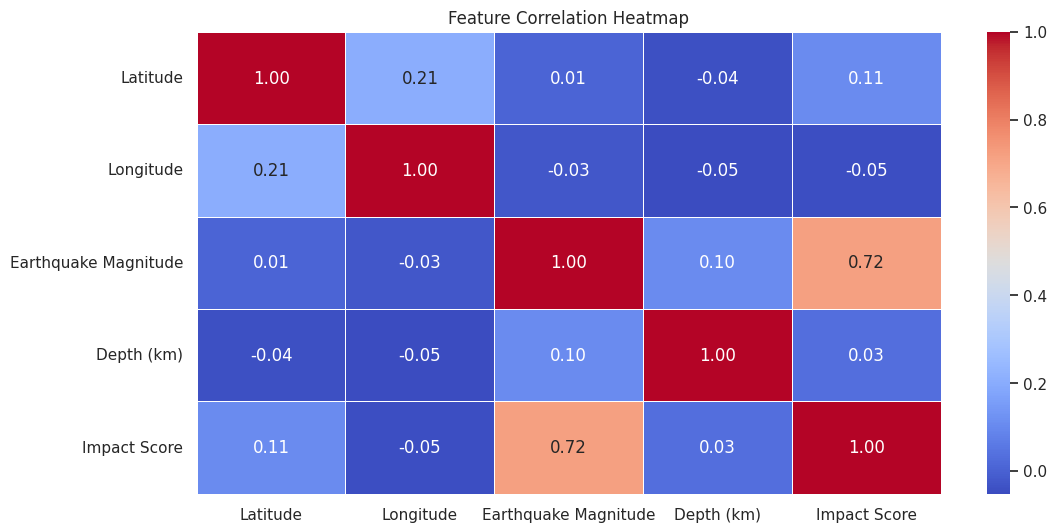

In [9]:
correlation_matrix = X.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [10]:
impact_correlations = (
    correlation_matrix["Impact Score"]
    .drop("Impact Score")
    .abs()
    .sort_values(ascending=False)
    .to_frame("Absolute Correlation with Impact Score")
)

impact_correlations

,Absolute Correlation with Impact Score
Earthquake Magnitude,0.718138
Latitude,0.106140
Longitude,0.045092
Depth (km),0.033599


## 7. Feature Distribution Visualisations

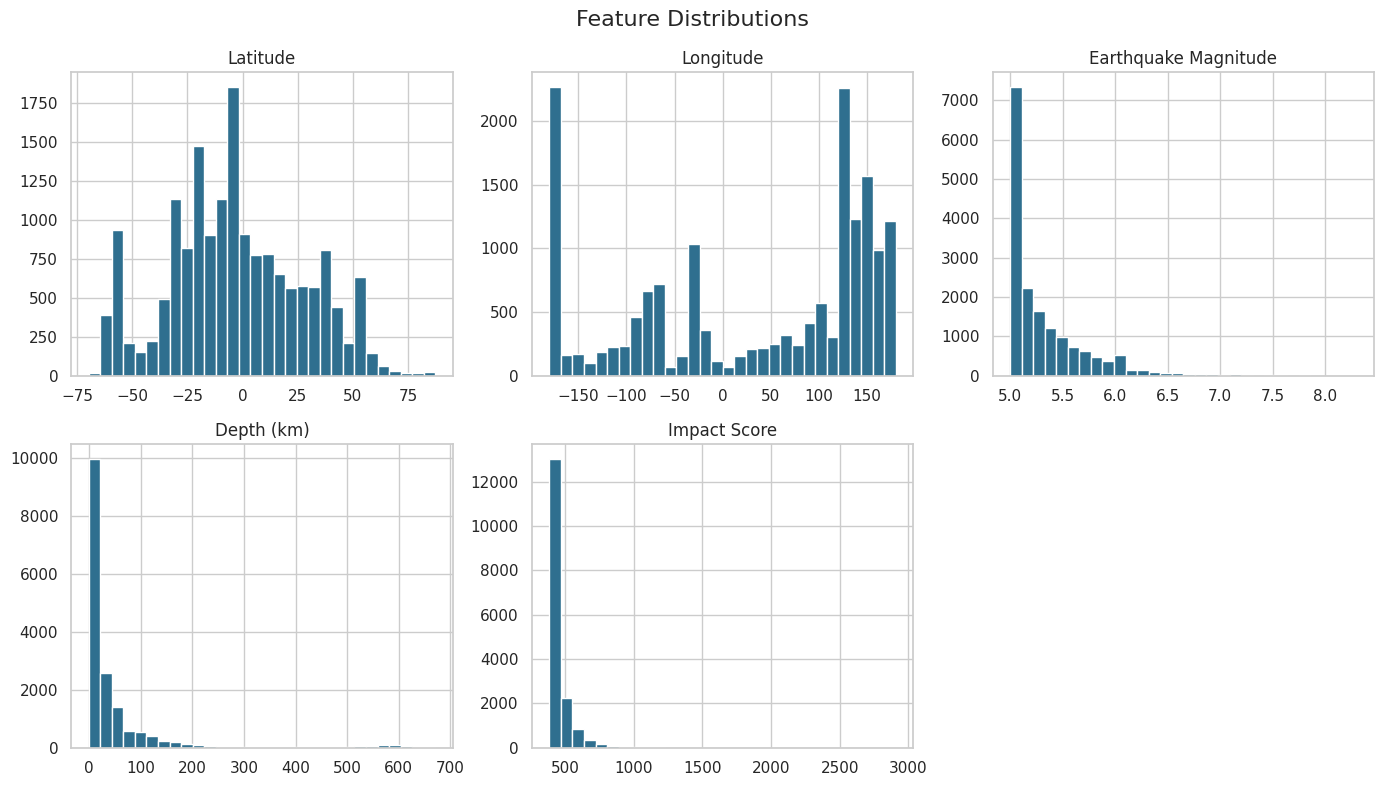

In [11]:
X.hist(
    bins=30,
    layout=(2, 3),
    figsize=(14, 8),
    color="#2f6f8f",
    edgecolor="white",
)

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

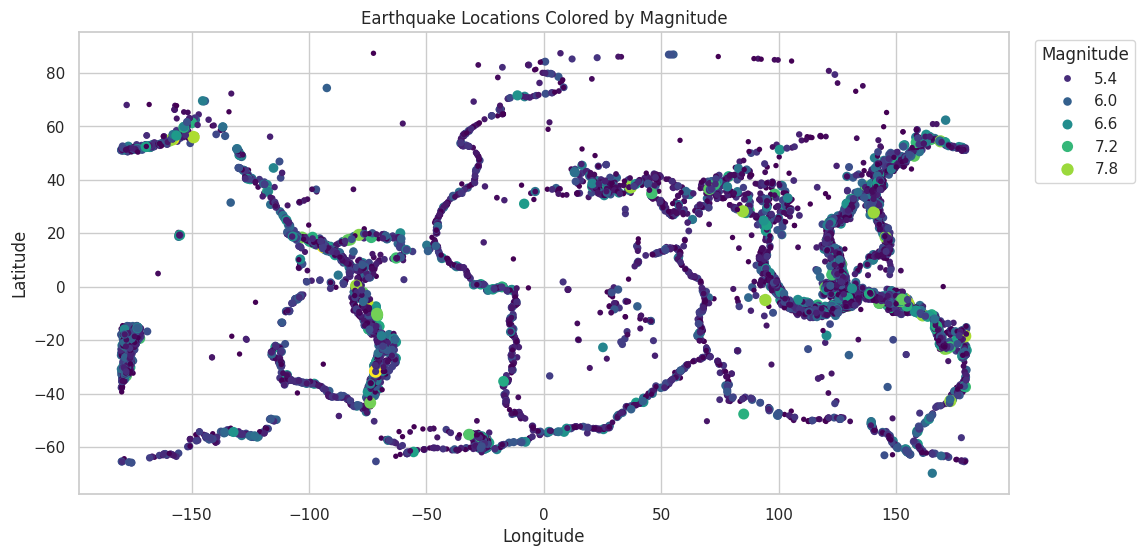

In [12]:
sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="Earthquake Magnitude",
    size="Earthquake Magnitude",
    palette="viridis",
    sizes=(15, 90),
    linewidth=0,
)

plt.title("Earthquake Locations Colored by Magnitude")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Magnitude", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

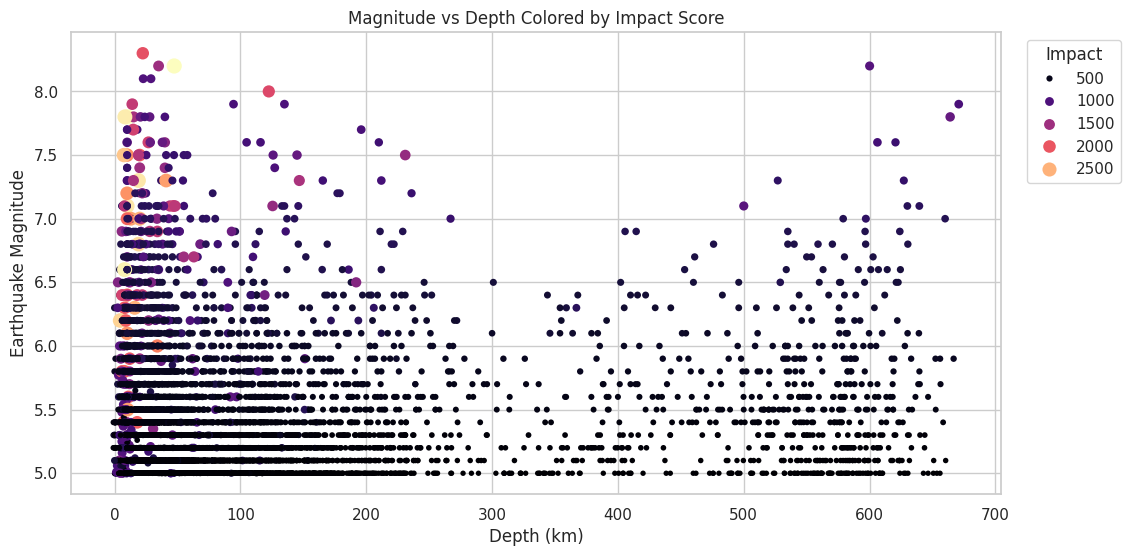

In [13]:
sns.scatterplot(
    data=df,
    x="Depth (km)",
    y="Earthquake Magnitude",
    hue="Impact Score",
    size="Impact Score",
    palette="magma",
    sizes=(15, 120),
    linewidth=0,
)

plt.title("Magnitude vs Depth Colored by Impact Score")
plt.xlabel("Depth (km)")
plt.ylabel("Earthquake Magnitude")
plt.legend(title="Impact", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## 8. Feature Scaling

HDBSCAN uses distance-based density. Features must be scaled so one column does not dominate only because of its unit size.

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.09536581,  0.93407493, -0.57758189,  0.05601578, -0.40235779],
       [ 0.67018516, -1.04322986,  0.65928957,  0.09942014,  0.34819608],
       [-1.71784833, -0.47571699,  1.64878673, -0.17122791,  0.71982954],
       [ 1.47763634, -0.13226775, -0.82495618, -0.42712924, -0.48251403],
       [ 0.14203596,  0.71328026,  0.16454099, -0.26064014, -0.04529818]])

## 9. Density Check for Parameter Reasoning

HDBSCAN does not need a manually selected `eps` value.

Still, nearest-neighbor distances help us understand the density structure of the data before choosing `min_cluster_size` and `min_samples`.

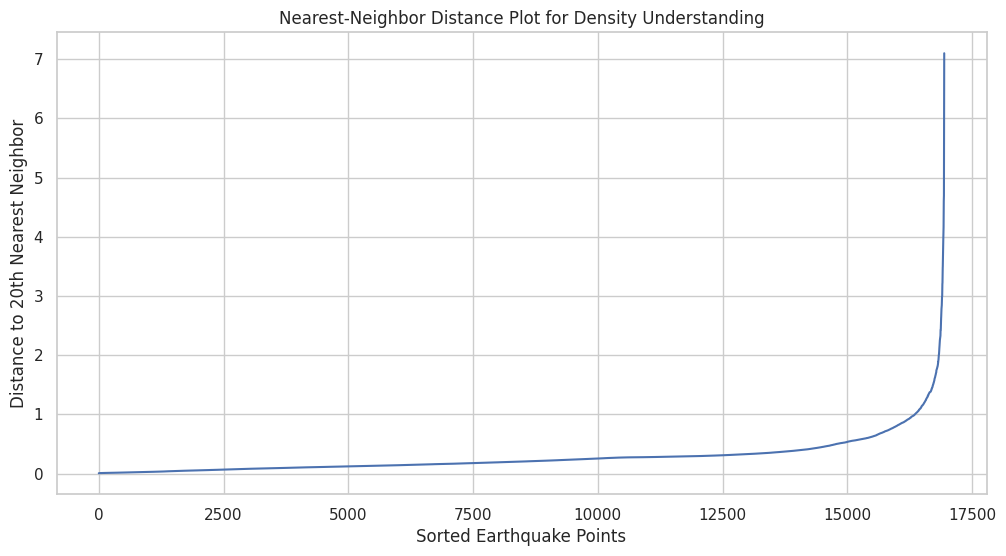

In [15]:
nearest_neighbor_count = 20

neighbors = NearestNeighbors(n_neighbors=nearest_neighbor_count)
neighbors.fit(X_scaled)

distances, neighbor_indices = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.plot(k_distances)
plt.title("Nearest-Neighbor Distance Plot for Density Understanding")
plt.xlabel("Sorted Earthquake Points")
plt.ylabel("Distance to 20th Nearest Neighbor")
plt.show()

## 10. Choose HDBSCAN Hyperparameters

Parameter reasoning:

- `min_cluster_size` controls the smallest meaningful earthquake zone.
- Here, it is selected as about **0.5% of the dataset**, with a minimum of 50 points.
- `min_samples` controls noise sensitivity.
- Here, it is selected as about one-third of `min_cluster_size`, with a minimum of 10.

This avoids unexplained hardcoded values and ties the parameters to dataset size.

In [16]:
min_cluster_size = max(50, int(len(df) * 0.005))
min_samples = max(10, int(min_cluster_size / 3))

hdbscan_parameters = pd.DataFrame(
    {
        "Parameter": ["min_cluster_size", "min_samples"],
        "Value": [min_cluster_size, min_samples],
        "Reason": [
            "About 0.5% of the dataset, minimum 50",
            "About one-third of min_cluster_size, minimum 10",
        ],
    }
)

hdbscan_parameters

,Parameter,Value,Reason
0,min_cluster_size,84,"About 0.5% of the dataset, minimum 50"
1,min_samples,28,"About one-third of min_cluster_size, minimum 10"


## 11. Train HDBSCAN Model

HDBSCAN finds dense earthquake zones and marks weakly connected points as noise.

Cluster label `-1` means noise.

In [17]:
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
)

df["HDBSCAN_Cluster"] = hdbscan_model.fit_predict(X_scaled)
df["HDBSCAN_Probability"] = hdbscan_model.probabilities_

df[["Latitude", "Longitude", "HDBSCAN_Cluster", "HDBSCAN_Probability"]].head()

,Latitude,Longitude,HDBSCAN_Cluster,HDBSCAN_Probability
0,-6.1233,147.5932,-1,0.000000
1,17.2871,-97.4400,-1,0.000000
2,-55.7385,-27.1122,-1,0.000000
3,41.9788,15.4490,20,0.661101
4,1.1364,120.2317,19,1.000000


## 12. Cluster Summary

In [18]:
cluster_count = df.loc[df["HDBSCAN_Cluster"] != -1, "HDBSCAN_Cluster"].nunique()
noise_count = df["HDBSCAN_Cluster"].eq(-1).sum()
noise_percentage = noise_count / len(df) * 100

cluster_summary = pd.DataFrame(
    {
        "Metric": ["Number of Clusters", "Noise Points", "Noise Percentage"],
        "Value": [cluster_count, noise_count, round(noise_percentage, 2)],
    }
)

cluster_summary

,Metric,Value
0,Number of Clusters,28.00
1,Noise Points,9078.00
2,Noise Percentage,53.58


In [19]:
cluster_sizes = (
    df["HDBSCAN_Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Count")
)

cluster_sizes

,Cluster,Count
0,-1,9078
1,0,97
2,1,240
3,2,371
4,3,300
5,4,409
6,5,92
7,6,163
8,7,219
9,8,125


## 13. Cluster Quality Metrics

Noise points are removed before calculating metrics because label `-1` is not a real cluster.

Metrics:

- Silhouette Score: higher is better
- Davies-Bouldin Score: lower is better
- Calinski-Harabasz Score: higher is better

In [20]:
cluster_mask = df["HDBSCAN_Cluster"] != -1
valid_cluster_count = df.loc[cluster_mask, "HDBSCAN_Cluster"].nunique()

if valid_cluster_count > 1:
    silhouette = silhouette_score(X_scaled[cluster_mask], df.loc[cluster_mask, "HDBSCAN_Cluster"])
    davies_bouldin = davies_bouldin_score(X_scaled[cluster_mask], df.loc[cluster_mask, "HDBSCAN_Cluster"])
    calinski_harabasz = calinski_harabasz_score(X_scaled[cluster_mask], df.loc[cluster_mask, "HDBSCAN_Cluster"])
else:
    silhouette = np.nan
    davies_bouldin = np.nan
    calinski_harabasz = np.nan

quality_metrics = pd.DataFrame(
    {
        "Metric": ["Silhouette Score", "Davies-Bouldin Score", "Calinski-Harabasz Score"],
        "Value": [silhouette, davies_bouldin, calinski_harabasz],
        "Better Direction": ["Higher", "Lower", "Higher"],
    }
)

quality_metrics

,Metric,Value,Better Direction
0,Silhouette Score,0.114081,Higher
1,Davies-Bouldin Score,1.333392,Lower
2,Calinski-Harabasz Score,3169.645886,Higher


## 14. Average Properties of Each Cluster

In [21]:
cluster_profile = (
    df[df["HDBSCAN_Cluster"] != -1]
    .groupby("HDBSCAN_Cluster")[feature_columns]
    .mean()
    .round(2)
)

cluster_profile.head(10)

,Latitude,Longitude,Earthquake Magnitude,Depth (km),Impact Score
HDBSCAN_Cluster,,,,,
0,-16.58,158.30,5.33,553.22,438.15
1,-20.15,-178.67,5.28,545.35,430.45
2,51.94,-160.89,5.25,22.71,426.21
3,-25.89,-176.04,5.10,15.47,400.02
4,-25.51,-175.93,5.00,16.24,385.00
5,-23.43,-175.72,5.63,12.15,486.83
6,-24.26,-175.71,5.44,12.29,456.27
7,-26.11,-176.17,5.20,15.79,416.04
8,-24.91,-175.75,5.30,13.50,432.10


## 15. Geographic Cluster Visualization

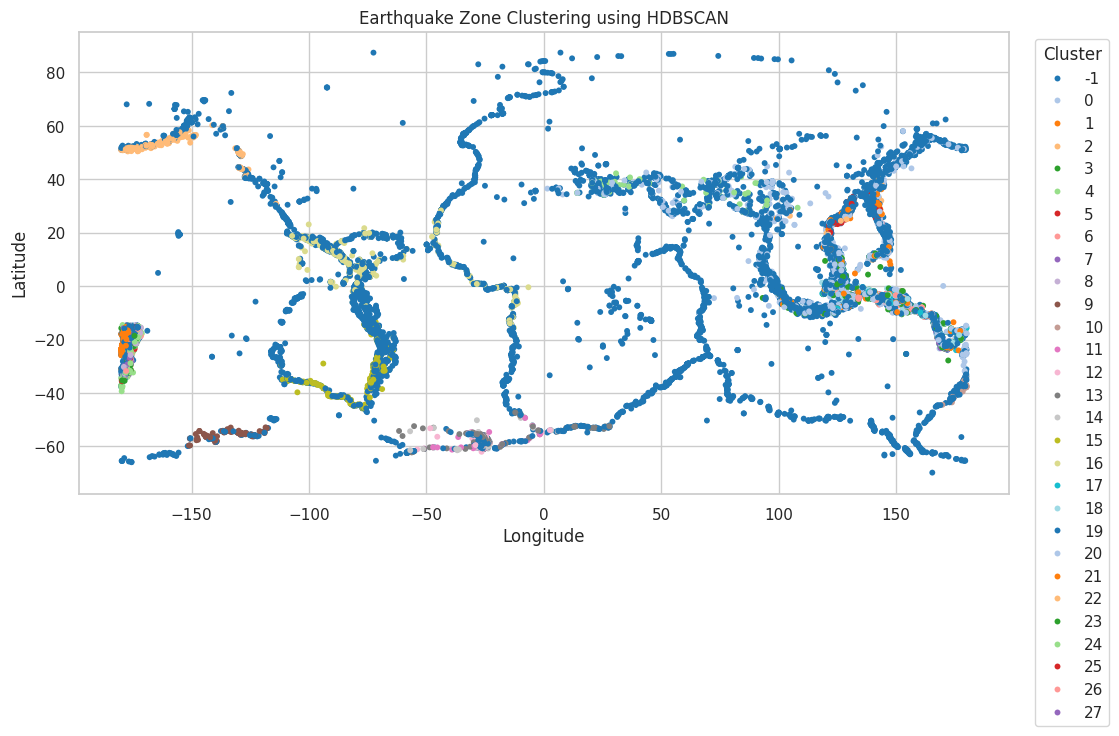

In [22]:
sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="HDBSCAN_Cluster",
    palette="tab20",
    s=18,
    linewidth=0,
)

plt.title("Earthquake Zone Clustering using HDBSCAN")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

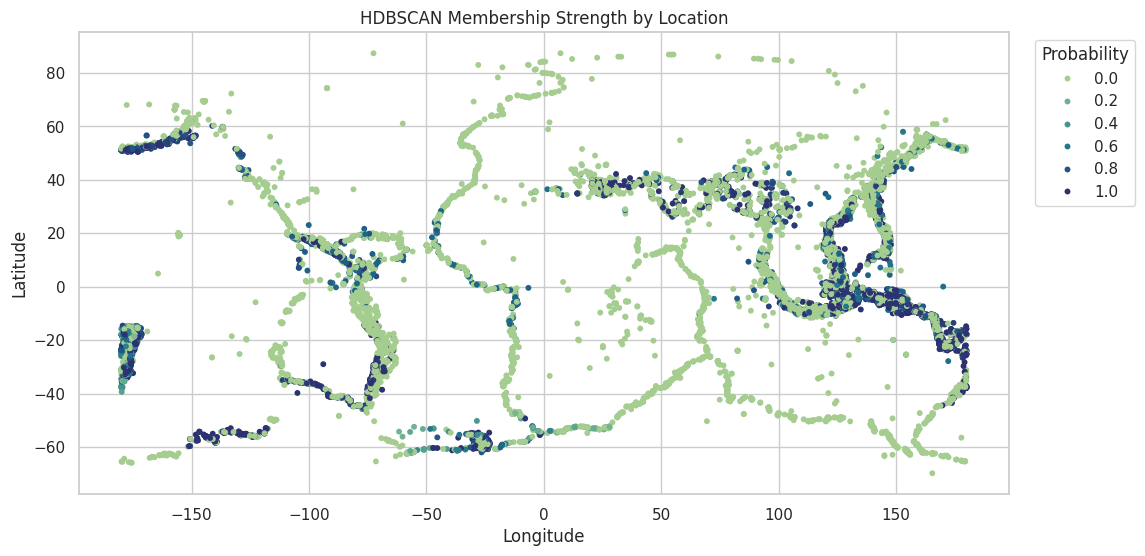

In [23]:
sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="HDBSCAN_Probability",
    palette="crest",
    s=18,
    linewidth=0,
)

plt.title("HDBSCAN Membership Strength by Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Probability", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## 16. PCA Visualization of the 5D Feature Space

The model was trained on 5 scaled features. PCA gives a 2D view of that feature space.

In [24]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PCA_1", "PCA_2"],
)

pca_df["HDBSCAN_Cluster"] = df["HDBSCAN_Cluster"]
pca_df["HDBSCAN_Probability"] = df["HDBSCAN_Probability"]

explained_variance = pd.DataFrame(
    {
        "Component": ["PCA_1", "PCA_2"],
        "Explained Variance Ratio": pca.explained_variance_ratio_,
    }
)

explained_variance

,Component,Explained Variance Ratio
0,PCA_1,0.348155
1,PCA_2,0.245619


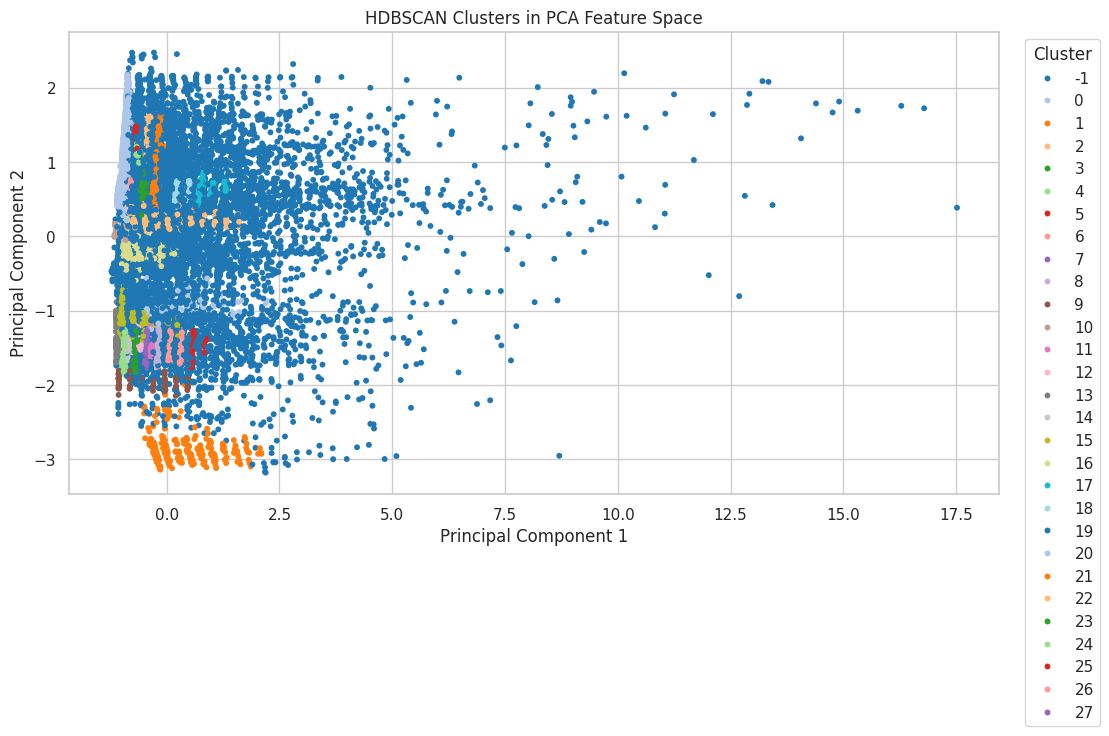

In [25]:
sns.scatterplot(
    data=pca_df,
    x="PCA_1",
    y="PCA_2",
    hue="HDBSCAN_Cluster",
    palette="tab20",
    s=18,
    linewidth=0,
)

plt.title("HDBSCAN Clusters in PCA Feature Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## 17. Cluster Size and Noise Visualization

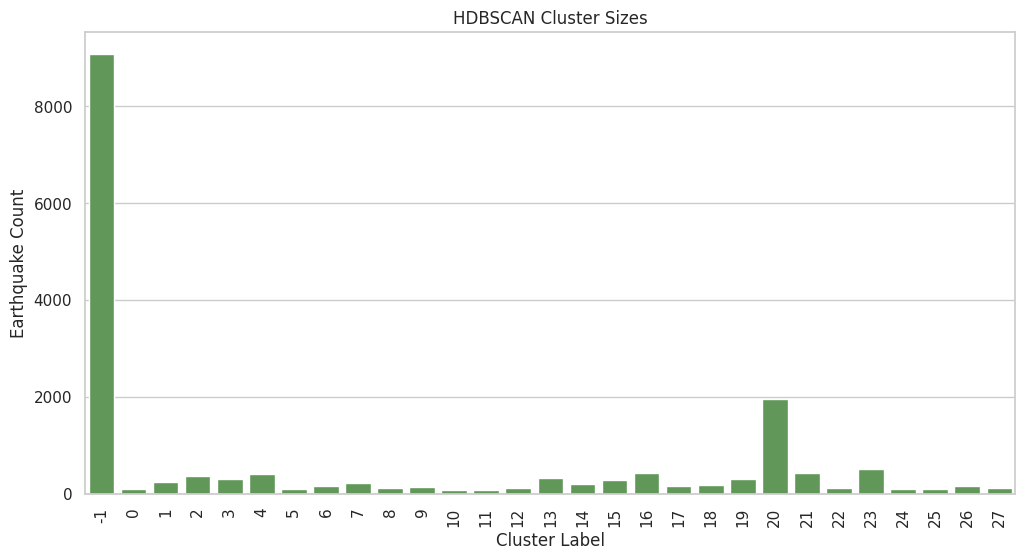

In [26]:
sns.barplot(
    data=cluster_sizes,
    x="Cluster",
    y="Count",
    color="#59a14f",
)

plt.title("HDBSCAN Cluster Sizes")
plt.xlabel("Cluster Label")
plt.ylabel("Earthquake Count")
plt.xticks(rotation=90)
plt.show()

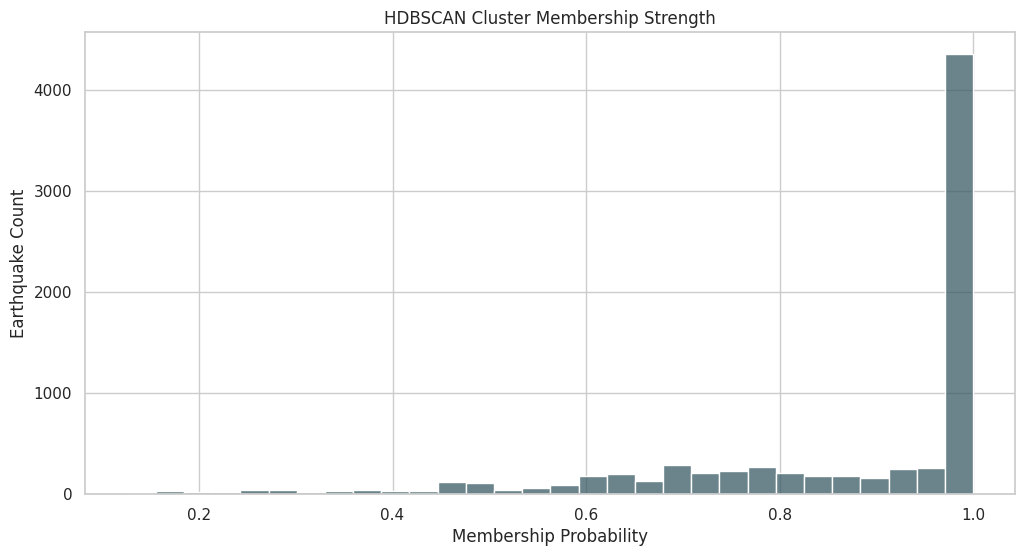

In [27]:
sns.histplot(
    data=df[df["HDBSCAN_Cluster"] != -1],
    x="HDBSCAN_Probability",
    bins=30,
    color="#395b64",
)

plt.title("HDBSCAN Cluster Membership Strength")
plt.xlabel("Membership Probability")
plt.ylabel("Earthquake Count")
plt.show()

## 18. Final Interpretation

- HDBSCAN is suitable because earthquake zones can have different densities.
- The model automatically detects noise points instead of forcing every earthquake into a cluster.
- PCA visualization shows the cluster structure in the scaled feature space.
- The correlation heatmap should be checked carefully because Impact Score may repeat information from magnitude or depth.
- For a stronger geospatial project, use Haversine distance or feature weighting for latitude and longitude.

## 19. Save Final Clustered Dataset

In [28]:
output_path = "earthquake_zone_hdbscan_clustered_results.csv"

df.to_csv(output_path, index=False)

output_path

'earthquake_zone_hdbscan_clustered_results.csv'